In [1]:
import aerosandbox as asb
from cessna152 import airplane
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

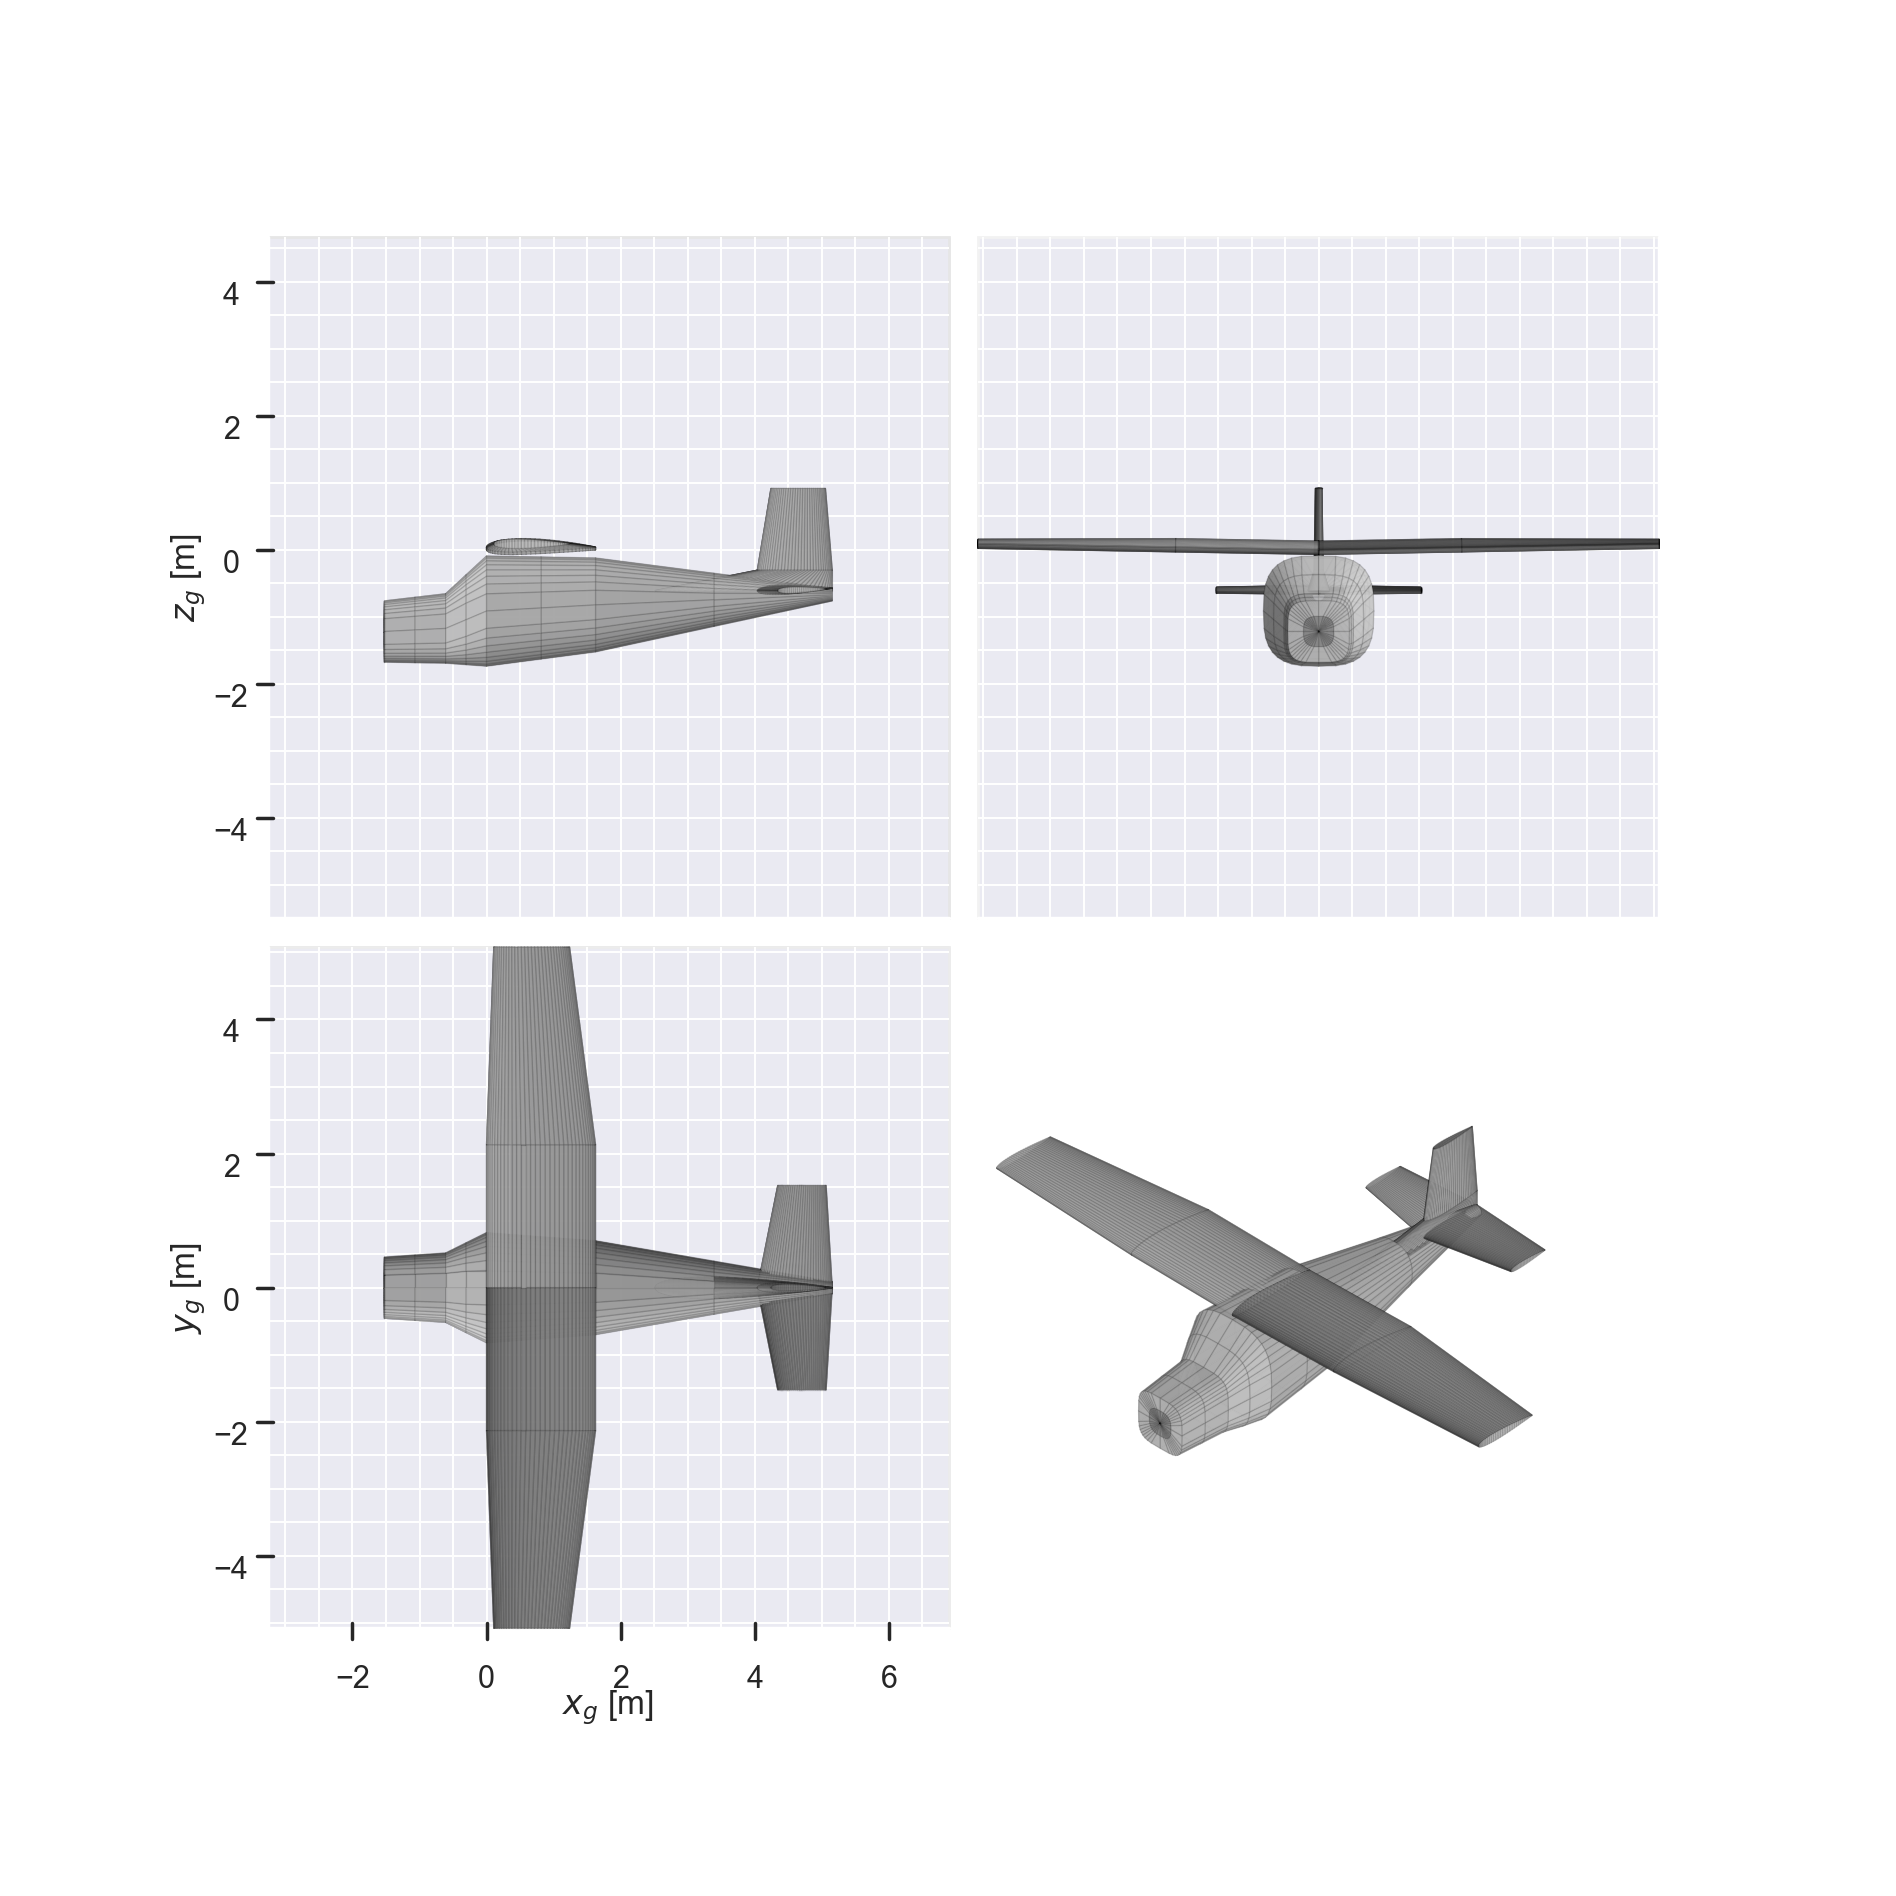

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [2]:
airplane.draw_three_view()

In [3]:
op_point = asb.OperatingPoint(
    velocity=50.0,  # m/s
    alpha=5.0,  # degrees
)

# LLT

In [4]:
aero_LLT = asb.LiftingLine(airplane=airplane, op_point=op_point, spanwise_spacing_function=np.cosspace,spanwise_resolution=30).run()

In [5]:
aero_LLT['wing_aero_components'].keys()

dict_keys(['Wing', 'Horizontal Stabilizer', 'Vertical Stabilizer'])

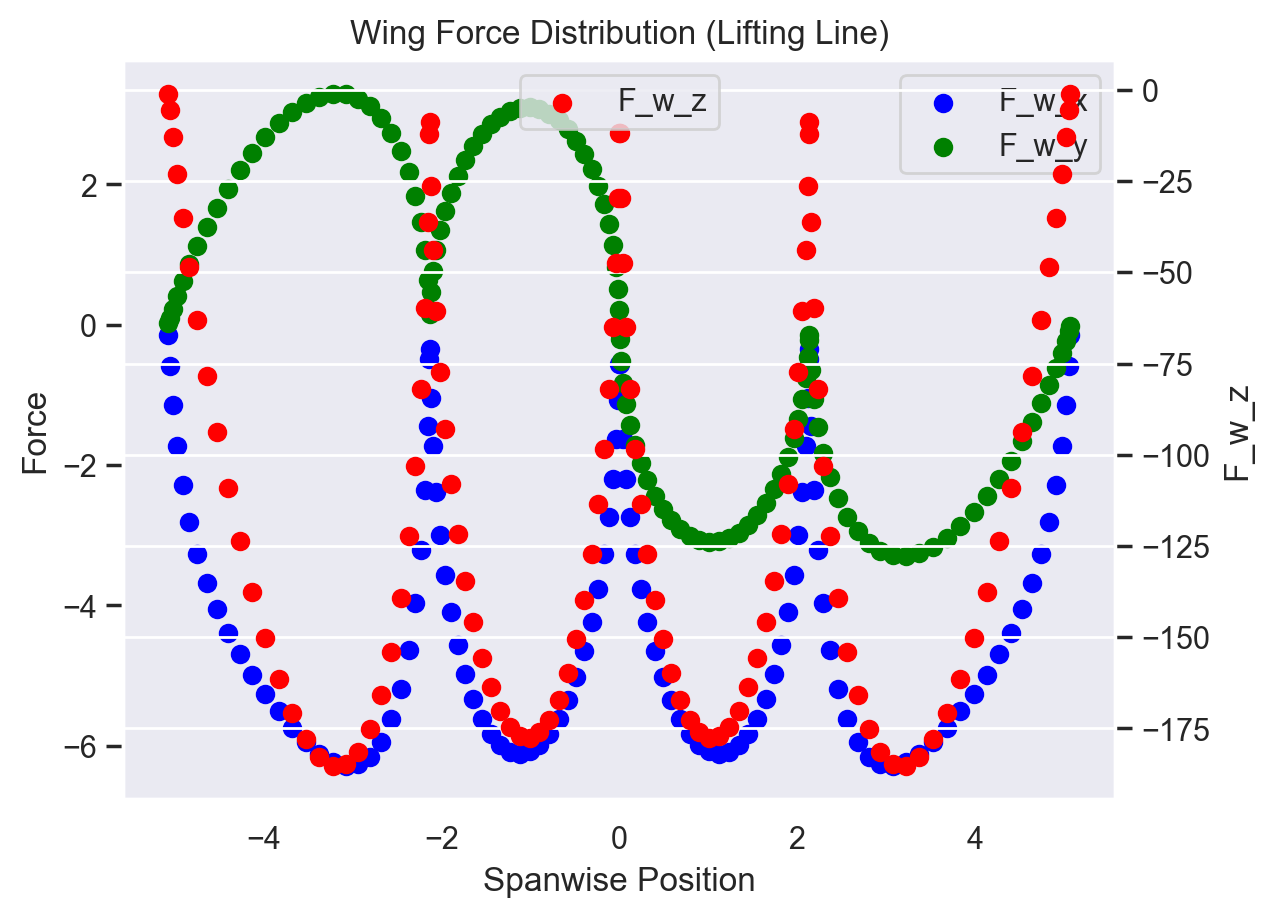

In [6]:
# Plot wing forces from lifting line
y = aero_LLT['wing_aero_components']['Wing'].panel_centers[:, 1]  # Spanwise position
F_w = np.array(aero_LLT['wing_aero_components']['Wing'].panel_forces_w)
fig, ax = plt.subplots()

ax.scatter(y, F_w[:, 0], label='F_w_x',color='blue')
second_ax = ax.twinx()
ax.scatter(y, F_w[:, 1], label='F_w_y',color='green')
second_ax.scatter(y, F_w[:, 2], label='F_w_z',color='red')
second_ax.set_ylabel('F_w_z')
ax.set_xlabel('Spanwise Position')
ax.set_ylabel('Force')
ax.set_title('Wing Force Distribution (Lifting Line)')
ax.legend()
ax.grid()
second_ax.legend()

# VLM

In [4]:
aero_vlm = asb.VortexLatticeMethod(airplane=airplane, op_point=op_point,spanwise_resolution=30)

In [5]:
aero_vlm_res = aero_vlm.run()

In [6]:
aero_vlm_res['L']

np.float64(12029.383615590898)

In [7]:
airplane.wings

[Wing 'Wing' (3 xsecs, symmetric),
 Wing 'Horizontal Stabilizer' (2 xsecs, symmetric),
 Wing 'Vertical Stabilizer' (3 xsecs, asymmetric)]

Text(0, 0.5, 'y (m)')

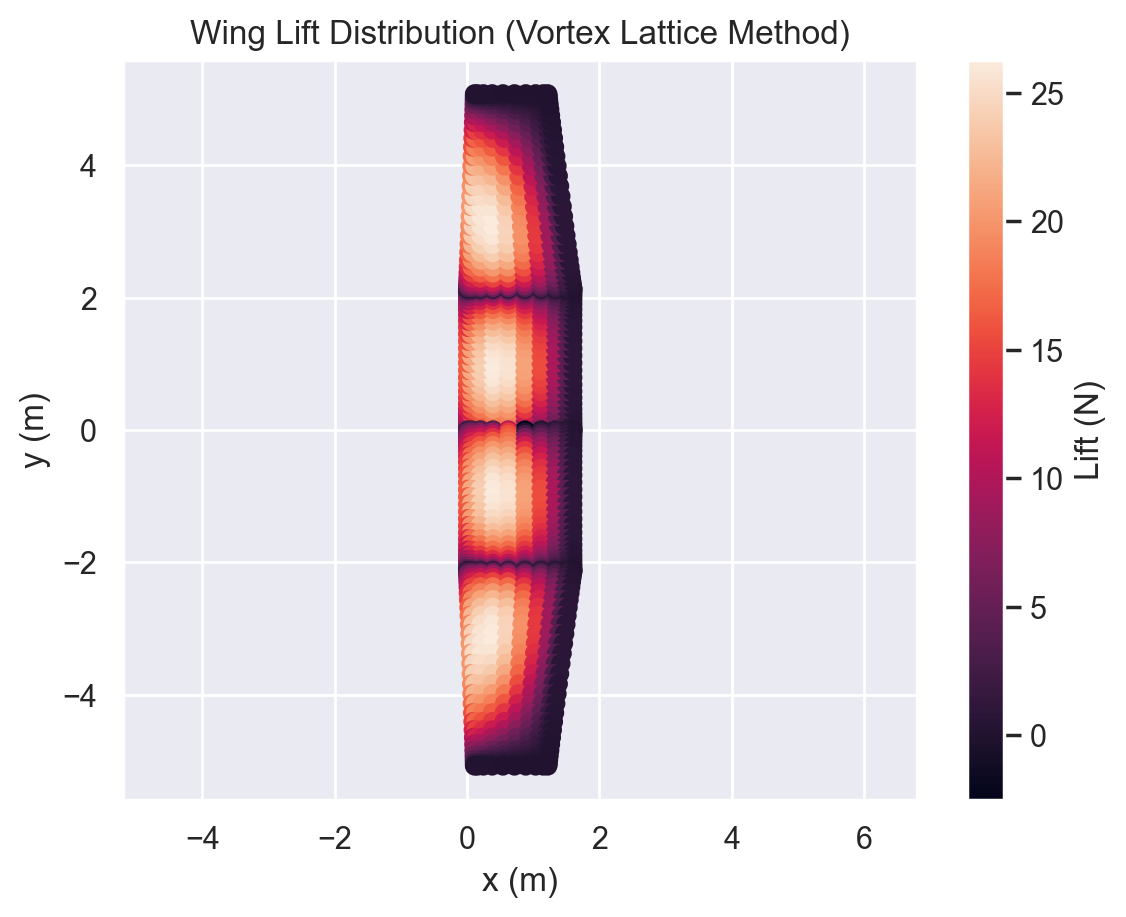

In [8]:
pdata = aero_vlm.get_panel_data(component="Wing")
x = pdata["xyz"][:, 0]
y = pdata["xyz"][:, 1]

plt.scatter(x, y, c=-pdata["F_w"][:, 2])
plt.axis("equal")
plt.grid(True)
plt.colorbar(label='Lift (N)')
plt.title('Wing Lift Distribution (Vortex Lattice Method)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')

Text(0, 0.5, 'Lift per Unit Length (N/m)')

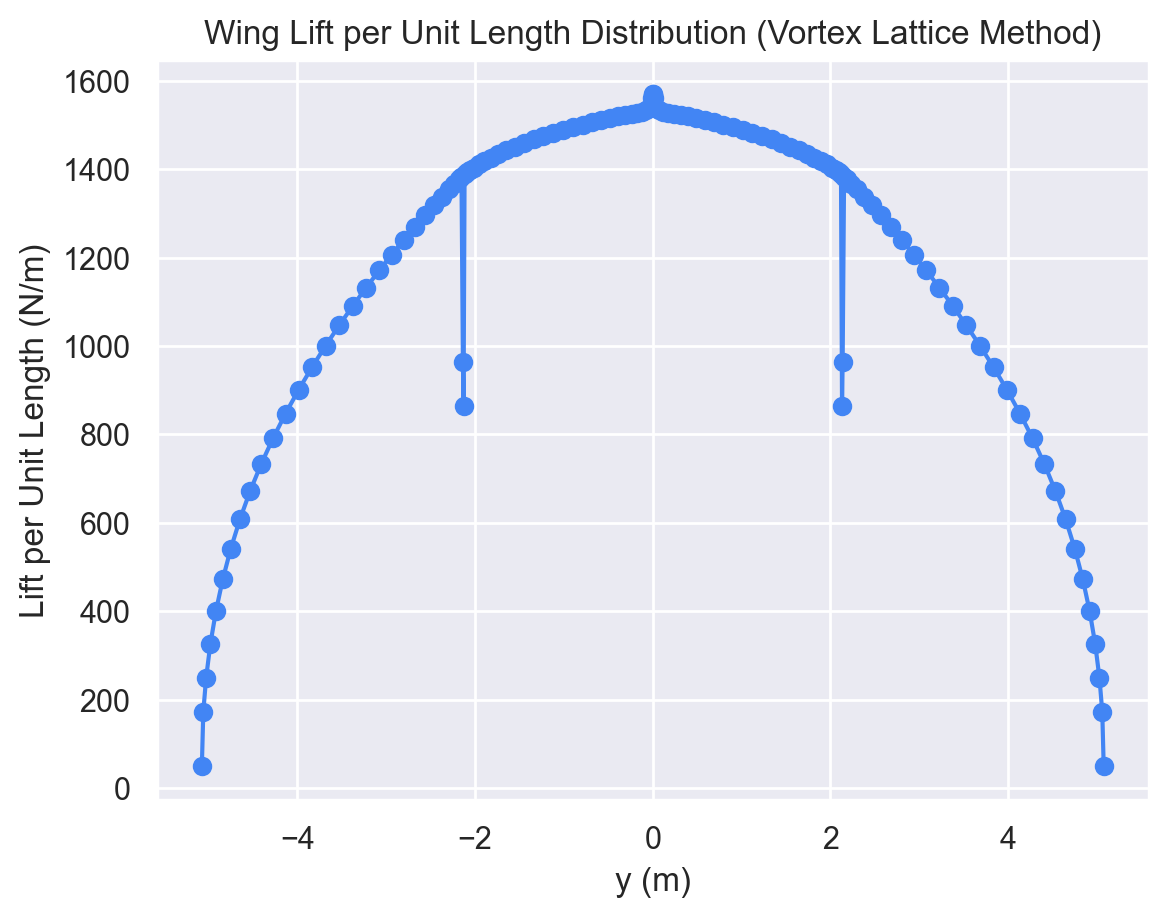

In [9]:
dist_w = aero_vlm.get_strip_distribution(component="Wing", axis="y")
dist_w = aero_vlm.get_strip_distribution(component="Wing", axis="y")

plt.plot(dist_w["y"], -dist_w["f_w_prime"][:, 2], marker="o")
plt.grid(True)
plt.title('Wing Lift per Unit Length Distribution (Vortex Lattice Method)')
plt.xlabel('y (m)')
plt.ylabel('Lift per Unit Length (N/m)')


Text(0, 0.5, 'Lift Coefficient (CL)')

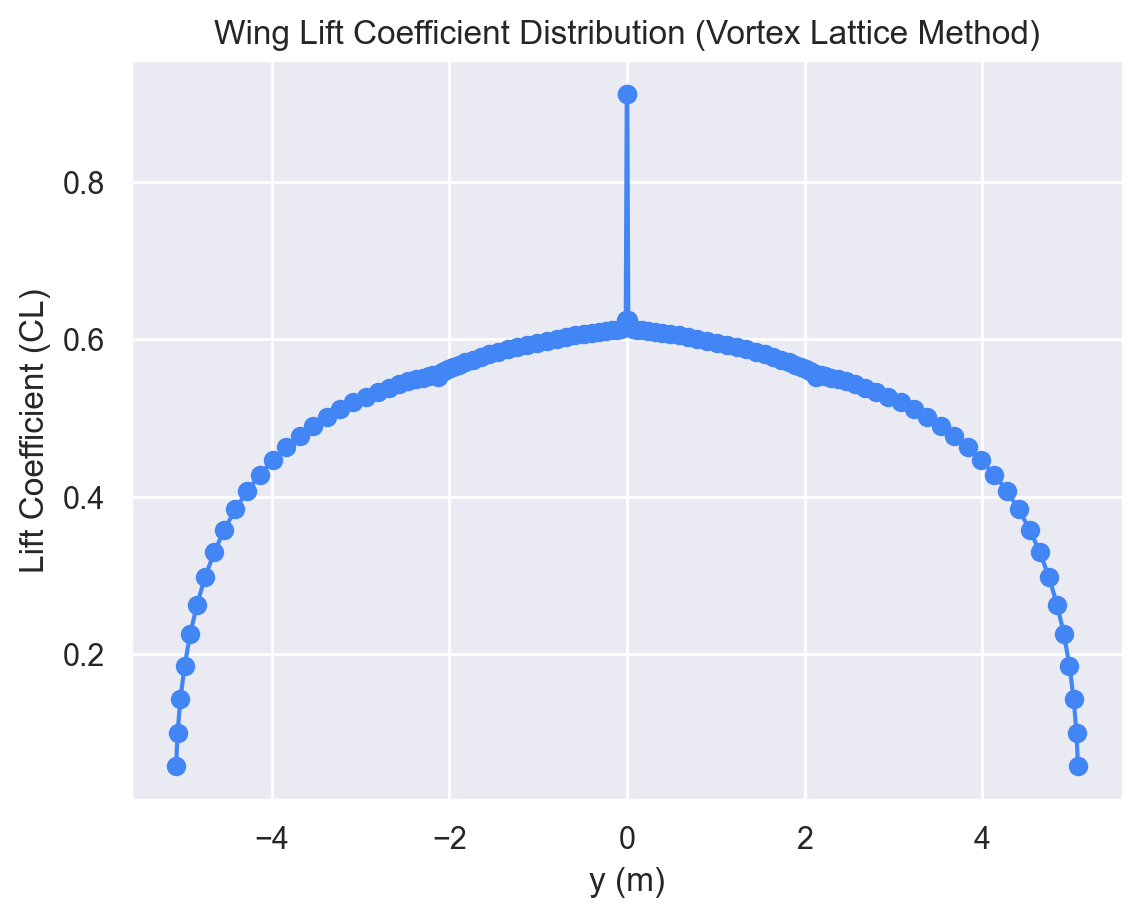

In [10]:
plt.plot(dist_w["y"], dist_w["CL_strip"], marker="o")
plt.grid(True)
plt.title('Wing Lift Coefficient Distribution (Vortex Lattice Method)')
plt.xlabel('y (m)')
plt.ylabel('Lift Coefficient (CL)')

Text(0, 0.5, 'Pitching Moment per Unit Length (N*m/m)')

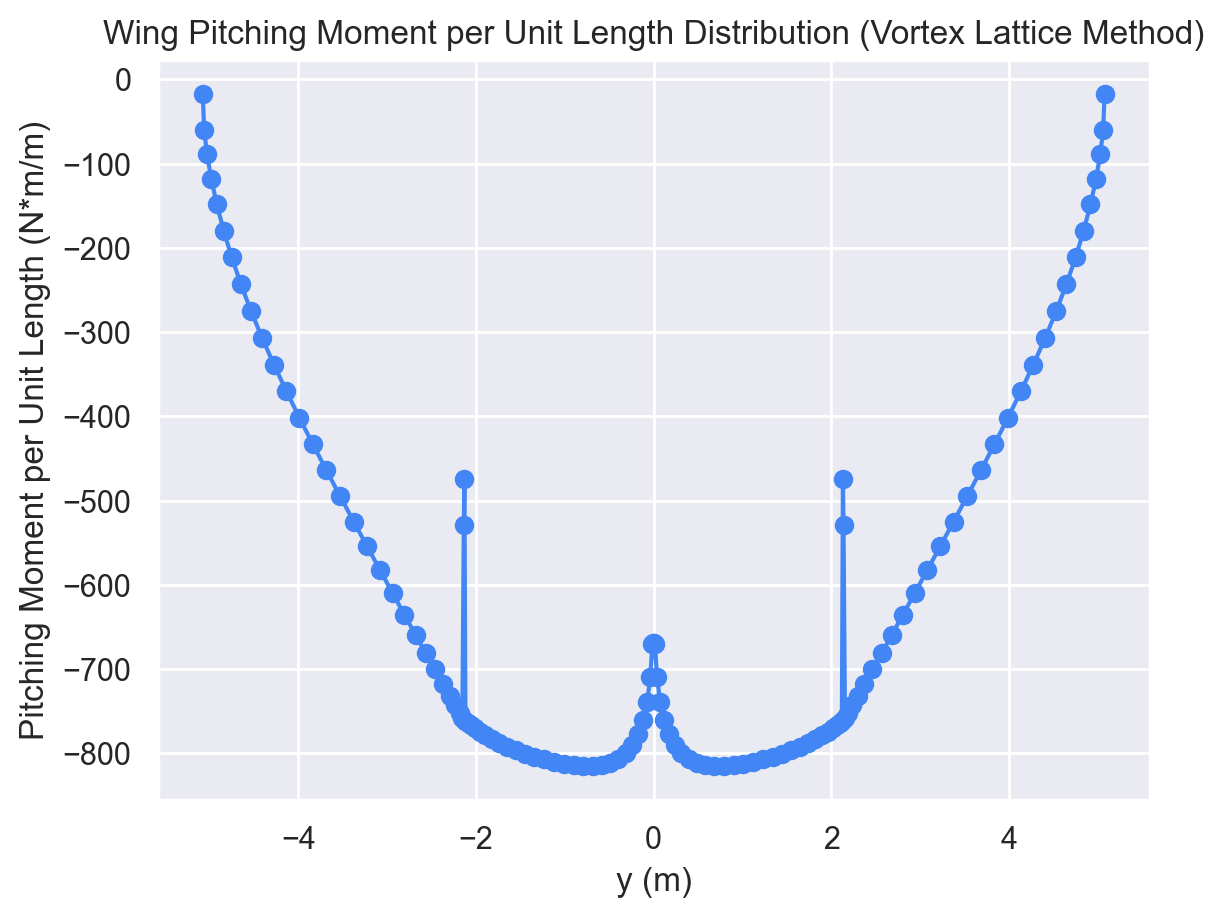

In [11]:
plt.plot(dist_w["y"], dist_w["m_w_prime"][:, 1], marker="o")
plt.grid(True)
plt.title('Wing Pitching Moment per Unit Length Distribution (Vortex Lattice Method)')
plt.xlabel('y (m)')
plt.ylabel('Pitching Moment per Unit Length (N*m/m)')

In [12]:
dist_w["Cm_strip"]

array([-0.01334235, -0.023121  , -0.03378908, -0.04470377, -0.05569607,
       -0.06661711, -0.07732515, -0.08770024, -0.09765592, -0.10714258,
       -0.1161431 , -0.12466388, -0.13272516, -0.14035407, -0.14757012,
       -0.15438086, -0.16079111, -0.16679891, -0.17239256, -0.17755452,
       -0.18226405, -0.18650044, -0.19024662, -0.19349279, -0.19623964,
       -0.19850005, -0.2002964 , -0.20164709, -0.20251756, -0.20231599,
       -0.20188997, -0.20312146, -0.20371548, -0.20448377, -0.20544228,
       -0.20653554, -0.20770751, -0.20891198, -0.21011304, -0.21128322,
       -0.21240126, -0.2134501 , -0.214415  , -0.21528159, -0.21603372,
       -0.21665096, -0.21710567, -0.21735981, -0.21736183, -0.21704448,
       -0.21632456, -0.21510508, -0.21327869, -0.21072841, -0.20731703,
       -0.20284995, -0.19698486, -0.18907526, -0.17874186, -0.25900014,
       -0.25900014, -0.17874186, -0.18907526, -0.19698486, -0.20284995,
       -0.20731703, -0.21072841, -0.21327869, -0.21510508, -0.21

In [13]:
pdata.keys()

dict_keys(['xyz', 'F_g', 'M_g', 'F_w', 'M_w', 'area', 'strip_ids', 'CDi_panel', 'CY_panel', 'CL_panel'])

Text(0, 0.5, 'Pitching Moment Coefficient')

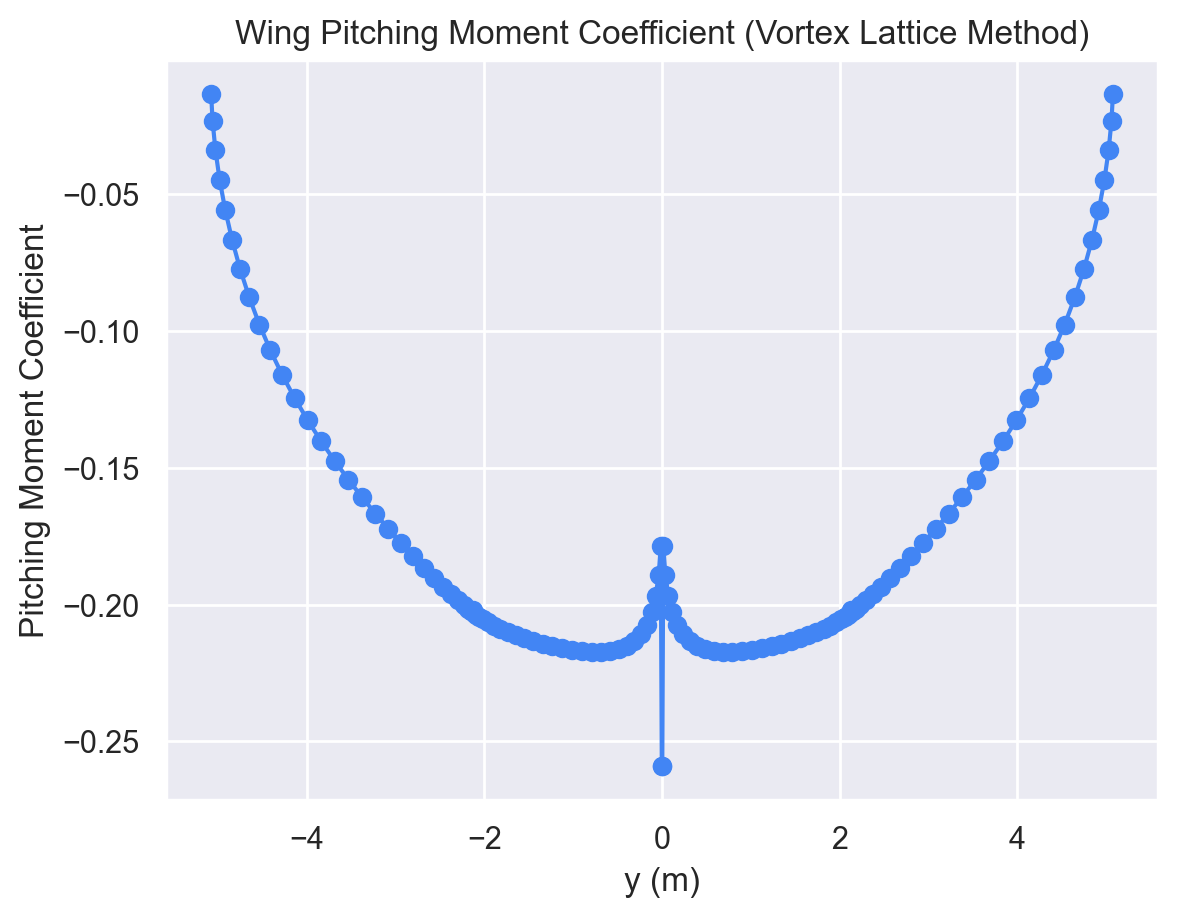

In [14]:
plt.plot(dist_w["y"], dist_w["Cm_strip"], marker="o")
plt.grid(True)
plt.title('Wing Pitching Moment Coefficient (Vortex Lattice Method)')
plt.xlabel('y (m)')
plt.ylabel('Pitching Moment Coefficient')